<a href="https://colab.research.google.com/github/nourelfeky/iris-classification-ml/blob/main/Iris(Task1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv("iris.csv")

df.head()

,Unnamed: 0,sepal_length,sepal_width,petal_length,petal_width,species
0,0,5.1,3.5,1.4,0.2,setosa
1,1,4.9,3.0,1.4,0.2,setosa
2,2,4.7,3.2,1.3,0.2,setosa
3,3,4.6,3.1,1.5,0.2,setosa
4,4,5.0,3.6,1.4,0.2,setosa


In [28]:
df.columns

Index(['Unnamed: 0', 'sepal_length', 'sepal_width', 'petal_length',
       'petal_width', 'species'],
      dtype='object')

In [29]:
df = df.drop("Unnamed: 0", axis=1)

In [30]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [31]:
df.shape

(157, 5)

In [32]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  156 non-null    float64
 1   sepal_width   156 non-null    float64
 2   petal_length  156 non-null    float64
 3   petal_width   155 non-null    float64
 4   species       157 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.3+ KB


In [33]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,156.000000,156.000000,156.000000,155.000000
mean,5.832692,3.067949,3.716026,1.190323
std,0.823929,0.433141,1.778818,0.768011
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.500000,0.300000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.400000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [34]:
df.isnull().sum()

,0
sepal_length,1
sepal_width,1
petal_length,1
petal_width,2
species,0


In [35]:
df[df.isnull().any(axis=1)]

,sepal_length,sepal_width,petal_length,petal_width,species
150,NaN,3.5,1.4,NaN,setosa
151,5.1,3.5,NaN,0.2,setosa
153,5.1,NaN,1.4,NaN,setosa


In [36]:
df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']] = \
df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].fillna(
    df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].mean()
)

In [37]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [38]:
df["species"].value_counts()

,count
species,
setosa,55
virginica,52
versicolor,50


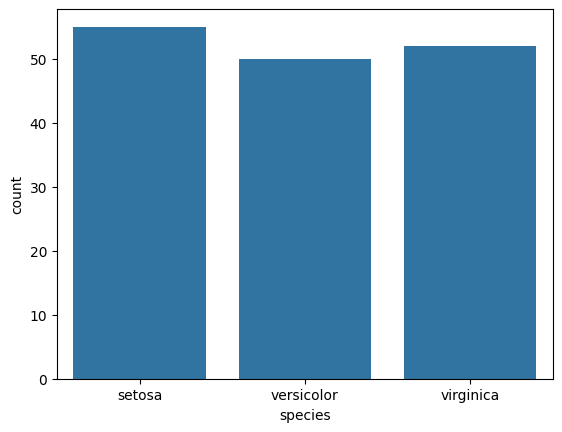

In [39]:
sns.countplot(data=df, x="species")
plt.show()

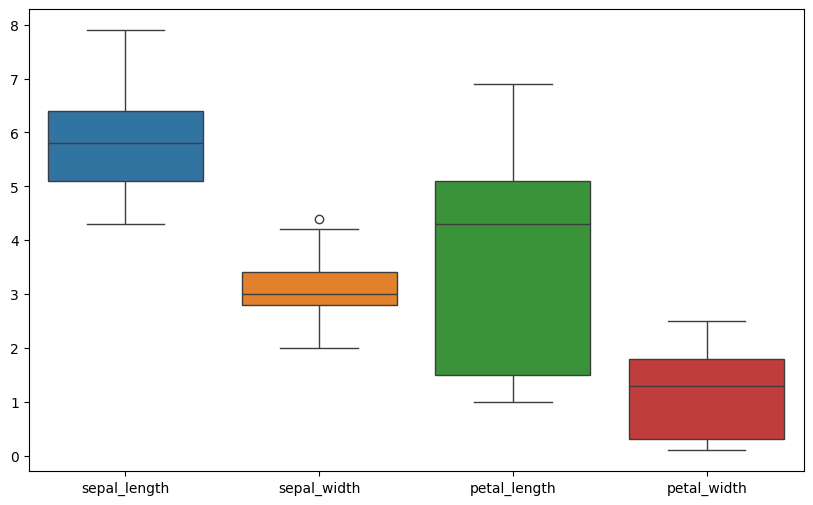

In [40]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df)

plt.show()

In [41]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

X = df[features]
y = df['species']

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9375
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.82      0.90        11

    accuracy                           0.94        32
   macro avg       0.94      0.94      0.94        32
weighted avg       0.95      0.94      0.94        32



In [45]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.90625
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       0.77      1.00      0.87        10
   virginica       1.00      0.73      0.84        11

    accuracy                           0.91        32
   macro avg       0.92      0.91      0.90        32
weighted avg       0.93      0.91      0.90        32



In [46]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", random_state=42)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9375
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.82      0.90        11

    accuracy                           0.94        32
   macro avg       0.94      0.94      0.94        32
weighted avg       0.95      0.94      0.94        32



In [47]:
print("Model Accuracy Comparison")
print("-------------------------")
print("Logistic Regression:", round(log_accuracy, 4))
print("KNN:", round(knn_accuracy, 4))
print("SVM:", round(svm_accuracy, 4))

Model Accuracy Comparison
-------------------------
Logistic Regression: 0.9375
KNN: 0.9062
SVM: 0.9375
